# Import Libraries

In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,roc_curve,roc_auc_score
from sklearn.model_selection import train_test_split

# Load Data

In [479]:
df=pd.read_csv("/content/drive/MyDrive/ICT - ML AI/Datasets/House_Pricing.csv")

# EDA

In [480]:
df.shape

(21613, 21)

In [481]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [482]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [483]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Preprocessing


## Duplicate removal

In [484]:
df.duplicated().sum()

np.int64(0)

In [485]:
df.drop_duplicates(inplace=True)

In [486]:
# 1. Transpose the DataFrame and call duplicated()
duplicate_cols = df.T.duplicated()

# 2. View which column names are duplicates
print(df.columns[duplicate_cols])

Index([], dtype='object')


In [487]:
# Removing the ID columns
df.drop(columns='ID',inplace=True)

## Handling Missing Values

In [488]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


In [489]:
(df.isna().sum()/len(df))*100

,0
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581
Condition of the House,0.000000


In [490]:
'''
# Dropping rows where missing value percent is less than 3%
missing_rows=['Sale Price','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Area of the House from Basement (in Sqft)','Zipcode','Latitude','Longitude','Living Area after Renovation (in Sqft)']
df.dropna(subset=missing_rows, inplace=True)
'''

"\n# Dropping rows where missing value percent is less than 3%\nmissing_rows=['Sale Price','No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Area of the House from Basement (in Sqft)','Zipcode','Latitude','Longitude','Living Area after Renovation (in Sqft)']\ndf.dropna(subset=missing_rows, inplace=True)\n"

In [491]:
# Dropping columns where missing value percentage is greater than 70%
df.drop(columns='No of Times Visited',inplace=True)

In [492]:
(df.isna().sum()/len(df))*100

,0
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
Condition of the House,0.000000
Overall Grade,0.000000


### Missing values - Numerical - KNNImputer

In [493]:
df_num = df.select_dtypes(exclude=object)

df_num.isna().sum()

,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),3
Basement Area (in Sqft),0
Age of House (in Years),0


In [494]:
num_imputer = KNNImputer(n_neighbors = 3)

df_num_imputed = pd.DataFrame(
    num_imputer.fit_transform(df_num),
    columns=df_num.columns
    )

df_num_imputed.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


### Missing values - Categorical - SimpleImputer

In [495]:
df_obj = df.select_dtypes(include=object)

df_obj.isna().sum()

,0
Date House was Sold,0
Waterfront View,0
Condition of the House,0


No need for impuatation as there are no null values in categorical columns.

### Combining data

In [496]:
df = pd.concat(
    [df_obj, df_num_imputed],
    axis=1
)

## Encoding

In [497]:
# Categorical columns
df_obj = df.select_dtypes(include='object')

In [498]:
# Viewing unique values
for col in df_obj:
  print(f"{col} : {df[col].unique()}")

Date House was Sold : ['14 October 2017' '14 December 2017' '15 February 2016' '14 May 2017'
 '14 June 2017' '15 January 2016' '15 April 2016' '15 March 2016'
 '14 July 2017' '14 August 2017' '14 November 2017' '14 September 2017'
 '15 May 2016']
Waterfront View : ['No' 'Yes']
Condition of the House : ['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


In [499]:
# Convert to datetime format
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])

# Extract useful numeric features
df['Selling_Year'] = df['Date House was Sold'].dt.year
df['Selling_Month'] = df['Date House was Sold'].dt.month

# Drop the original date column
df.drop(columns=['Date House was Sold'], inplace=True)

In [500]:
df_num = df.select_dtypes(exclude='object')
df_num.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


In [501]:
# Categorical columns
df_obj = df.select_dtypes(include='object')

In [502]:
# Viewing unique values
for col in df_obj:
  print(f"{col} : {df[col].unique()}")

Waterfront View : ['No' 'Yes']
Condition of the House : ['Fair' 'Excellent' 'Good' 'Bad' 'Okay']


### OneHot Encoder - Nominal

In [503]:
oh = OneHotEncoder(sparse_output=False, drop='first')

oh_encoded = pd.DataFrame(
    oh.fit_transform(df[['Waterfront View']]),
    columns=oh.get_feature_names_out(['Waterfront View']),
    index=df.index
)

In [504]:
df.head()

,Waterfront View,Condition of the House,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Selling_Year,Selling_Month
0,No,Fair,221900.0,3.0,1.00,1180.0,5650.0,1.0,7.0,1180.0,0.0,63.0,0.0,98178.0,47.5112,-122.257,1340.0,5650.0,2017,10
1,No,Fair,538000.0,3.0,2.25,2570.0,7242.0,2.0,7.0,2170.0,400.0,67.0,1991.0,98125.0,47.7210,-122.319,1690.0,7639.0,2017,12
2,No,Fair,180000.0,2.0,1.00,770.0,10000.0,1.0,6.0,770.0,0.0,85.0,0.0,98028.0,47.7379,-122.233,2720.0,8062.0,2016,2
3,No,Excellent,604000.0,4.0,3.00,1960.0,5000.0,1.0,7.0,1050.0,910.0,53.0,0.0,98136.0,47.5208,-122.393,1360.0,5000.0,2017,12
4,No,Fair,510000.0,3.0,2.00,1680.0,8080.0,1.0,8.0,1680.0,0.0,31.0,0.0,98074.0,47.6168,-122.045,1800.0,7503.0,2016,2


In [505]:
df = df.drop(columns='Waterfront View').join(oh_encoded)

### Label Encoder

In [506]:
lb = LabelEncoder()

df['Condition of the House'] = lb.fit_transform(df['Condition of the House'])

In [507]:
df.head()

,Condition of the House,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Selling_Year,Selling_Month,Waterfront View_Yes
0,2,221900.0,3.0,1.00,1180.0,5650.0,1.0,7.0,1180.0,0.0,63.0,0.0,98178.0,47.5112,-122.257,1340.0,5650.0,2017,10,0.0
1,2,538000.0,3.0,2.25,2570.0,7242.0,2.0,7.0,2170.0,400.0,67.0,1991.0,98125.0,47.7210,-122.319,1690.0,7639.0,2017,12,0.0
2,2,180000.0,2.0,1.00,770.0,10000.0,1.0,6.0,770.0,0.0,85.0,0.0,98028.0,47.7379,-122.233,2720.0,8062.0,2016,2,0.0
3,1,604000.0,4.0,3.00,1960.0,5000.0,1.0,7.0,1050.0,910.0,53.0,0.0,98136.0,47.5208,-122.393,1360.0,5000.0,2017,12,0.0
4,2,510000.0,3.0,2.00,1680.0,8080.0,1.0,8.0,1680.0,0.0,31.0,0.0,98074.0,47.6168,-122.045,1800.0,7503.0,2016,2,0.0


## Correlation

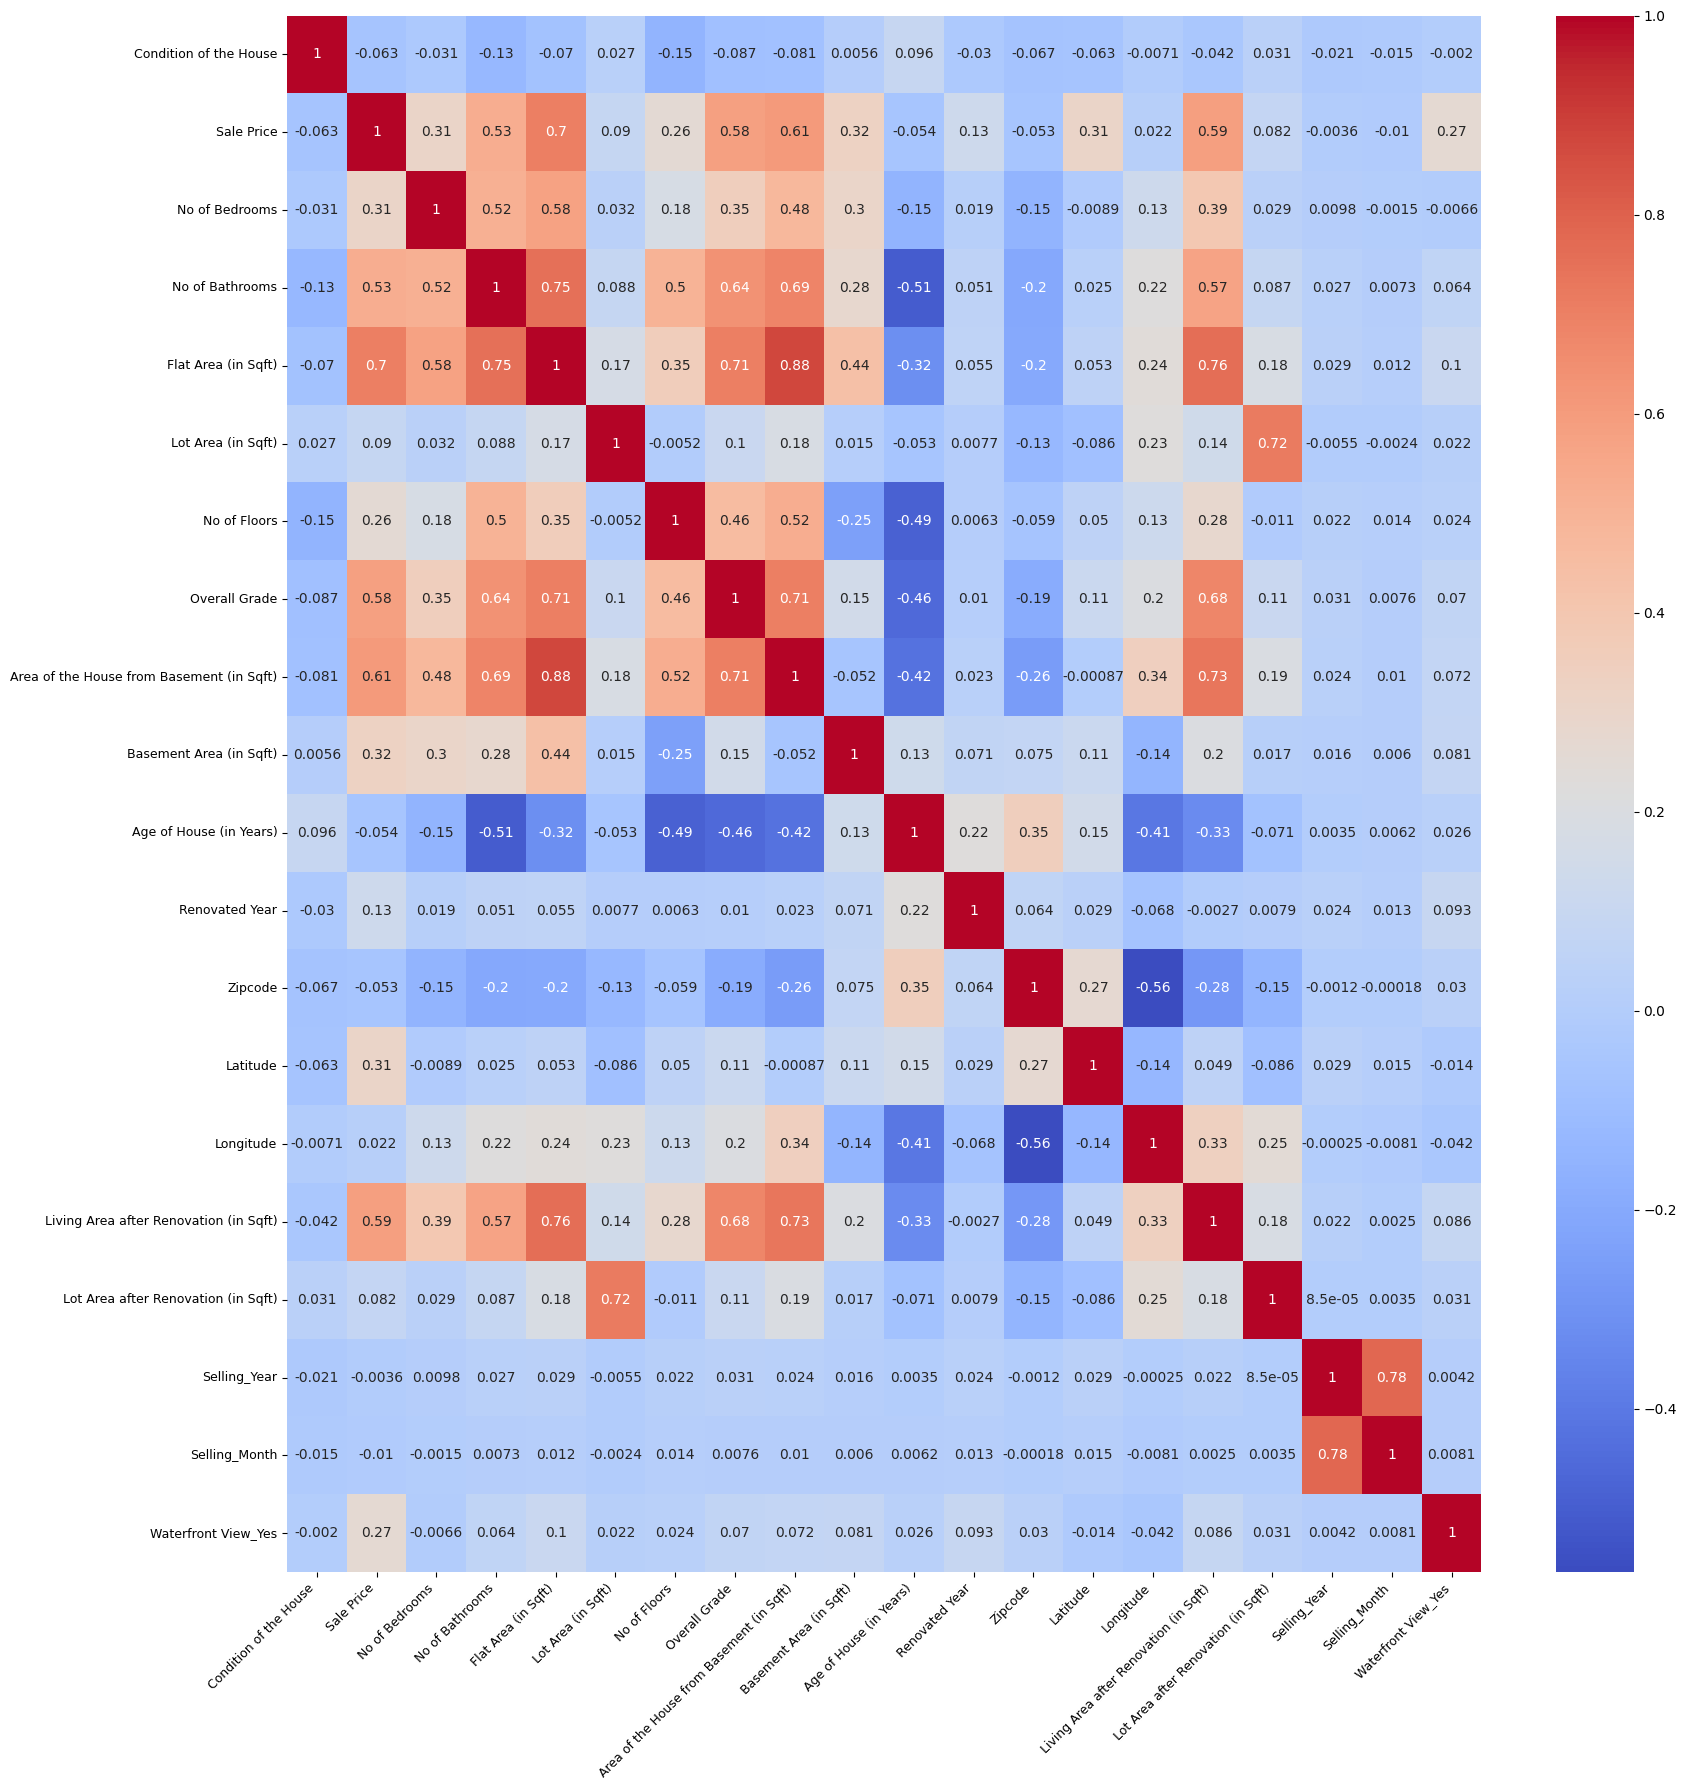

In [508]:
corr_result = df.corr()

n_features = len(corr_result.columns)
fig_dim = max(12, n_features * 0.9)

plt.figure(figsize=(fig_dim, fig_dim))

sns.heatmap(data=corr_result, cmap="coolwarm",annot=True)

# Rotate labels so they don't overlap or get cut off
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

In [509]:
print(df.corr().iloc[1])

Condition of the House                      -0.062964
Sale Price                                   1.000000
No of Bedrooms                               0.308489
No of Bathrooms                              0.525177
Flat Area (in Sqft)                          0.702059
Lot Area (in Sqft)                           0.089605
No of Floors                                 0.256787
Overall Grade                                0.580607
Area of the House from Basement (in Sqft)    0.605449
Basement Area (in Sqft)                      0.323764
Age of House (in Years)                     -0.054003
Renovated Year                               0.126443
Zipcode                                     -0.053133
Latitude                                     0.306846
Longitude                                    0.021566
Living Area after Renovation (in Sqft)       0.585357
Lot Area after Renovation (in Sqft)          0.082456
Selling_Year                                -0.003598
Selling_Month               

In [510]:
selected_features = ['Living Area after Renovation (in Sqft)','Area of the House from Basement (in Sqft)','Basement Area (in Sqft)','Flat Area (in Sqft)']

## Outliers

### Visualizing Outliers

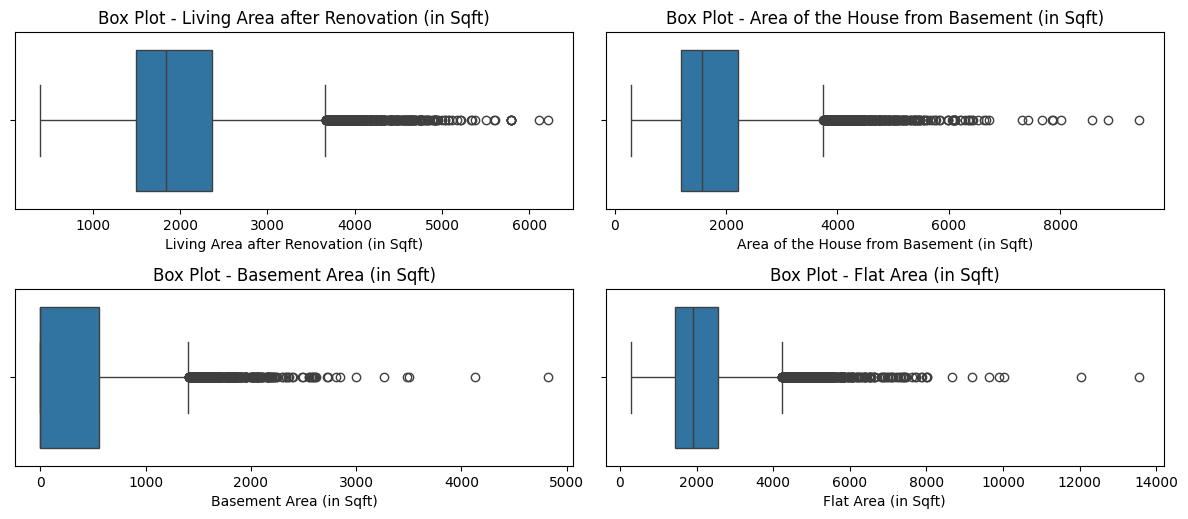

In [511]:
columns = selected_features

plt.figure(figsize=(12,10))

for i,col in enumerate(columns): # enumerate returns index along with values
  plt.subplot(len(columns),2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot - {col}")

plt.tight_layout()
plt.show()

### Treating Outliers

In [512]:
outlier_cols=['Living Area after Renovation (in Sqft)','Area of the House from Basement (in Sqft)','Basement Area (in Sqft)','Flat Area (in Sqft)']

In [513]:
# Before Handling Outlier
for i in outlier_cols:
  print(df[outlier_cols].describe())

for cols in outlier_cols:
# First and Third Qunatile
  Q1=df[cols].quantile(0.25)
  Q3=df[cols].quantile(0.75)

  # IQR
  IQR=Q3-Q1

  # Finding upper and lower bounds
  upper_bound=Q3+1.5*IQR
  lower_bound=Q1-1.5*IQR

  # Outlier
  outlier=df[(df[cols] < lower_bound) | (df[cols] > upper_bound) ]

  # Clipping
  df[cols] = df [cols].clip(upper=upper_bound,lower=lower_bound)

# After Handling Outlier
for i in outlier_cols:
  print(df[outlier_cols].describe())

       Living Area after Renovation (in Sqft)  \
count                            21613.000000   
mean                              1986.532133   
std                                685.389122   
min                                399.000000   
25%                               1490.000000   
50%                               1840.000000   
75%                               2360.000000   
max                               6210.000000   

       Area of the House from Basement (in Sqft)  Basement Area (in Sqft)  \
count                               21613.000000             21613.000000   
mean                                 1788.345348               291.509045   
std                                   827.934118               442.575043   
min                                   290.000000                 0.000000   
25%                                  1190.000000                 0.000000   
50%                                  1560.000000                 0.000000   
75%                

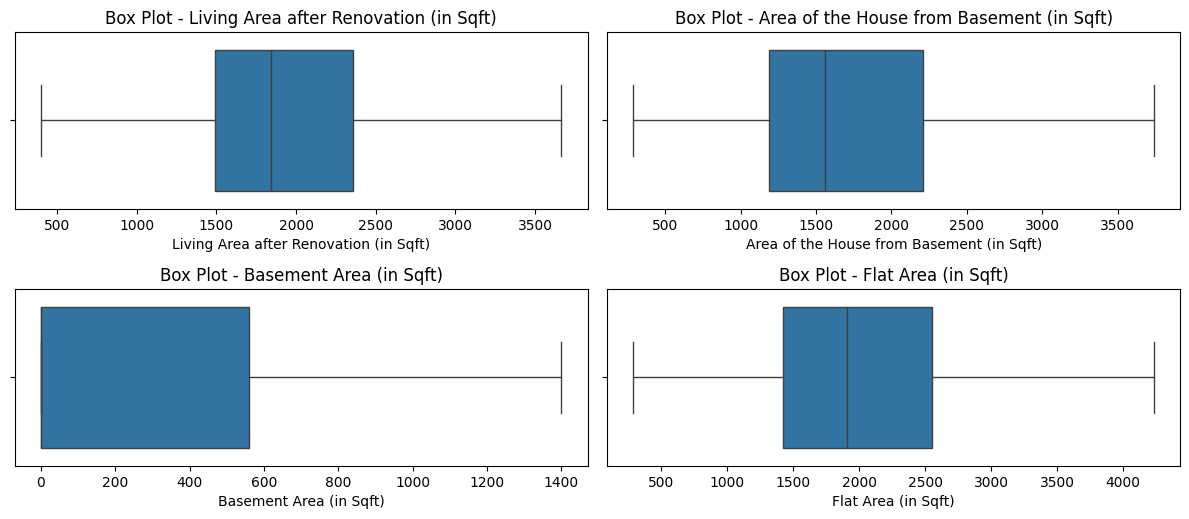

In [514]:
columns = selected_features

plt.figure(figsize=(12,10))

for i,col in enumerate(columns): # enumerate returns index along with values
  plt.subplot(len(columns),2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot - {col}")

plt.tight_layout()
plt.show()

# Train test Split

In [515]:
X = df[selected_features]
y = df['Sale Price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Standardization

In [516]:
scaler = StandardScaler()

X_train_scale=scaler.fit_transform(X_train)
X_test_scale=scaler.transform(X_test)

In [517]:
X_train_scale

array([[ 1.20276171,  0.01592472, -0.67734019, -0.32754774],
       [-1.08561259, -1.2732603 , -0.19519156, -1.2606655 ],
       [-1.24023248, -1.02331626, -0.46037331, -1.16496111],
       ...,
       [-0.43620908,  0.46319299, -0.67734019,  0.0791959 ],
       [-1.24023248, -1.82576816, -0.67734019, -2.00237449],
       [ 1.6202354 ,  1.79184285, -0.67734019,  1.28746377]])

In [518]:
X_test_scale

array([[ 0.64613012,  0.39741824, -0.67734019,  0.01938066],
       [ 0.61520614,  0.08169946,  1.90215499,  1.01231366],
       [ 2.61753365,  2.59429474, -0.67734019,  2.05309885],
       ...,
       [ 0.71416287,  0.87625839, -0.67734019,  0.45483561],
       [ 0.12042251,  0.63420733, -0.67734019,  0.23471552],
       [ 0.70797807,  1.0551657 , -0.67734019,  0.61753307]])